# Framingham Heart Disease Study Analysis

The Framingham Heart Study is a multigenerational, long term study designed to identify and understand characteristics that impact one's risk of developing coronary heart disease (CHD) in the next 10 years. This project's objective is to build and train a classification model to predict a given person's risk of developing CHD.

In [3]:
# Loading the raw data and importing necessary libraries
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

df = pd.read_csv("../data/framingham.csv")
df.head()

,male,age,education,currentSmoker,cigsPerDay,BPMeds,prevalentStroke,prevalentHyp,diabetes,totChol,sysBP,diaBP,BMI,heartRate,glucose,TenYearCHD
0,1,39,4.0,0,0.0,0.0,0,0,0,195.0,106.0,70.0,26.97,80.0,77.0,0
1,0,46,2.0,0,0.0,0.0,0,0,0,250.0,121.0,81.0,28.73,95.0,76.0,0
2,1,48,1.0,1,20.0,0.0,0,0,0,245.0,127.5,80.0,25.34,75.0,70.0,0
3,0,61,3.0,1,30.0,0.0,0,1,0,225.0,150.0,95.0,28.58,65.0,103.0,1
4,0,46,3.0,1,23.0,0.0,0,0,0,285.0,130.0,84.0,23.10,85.0,85.0,0


Investigating data integrity

In [10]:
# Size of the dataset
print(f'Rows: {df.shape[0]}')
print(f'Columns: {df.shape[1]}')

Rows: 4240
Columns: 16


In [11]:
# Summary of null or missing values
df.isna().sum()

male                 0
age                  0
education          105
currentSmoker        0
cigsPerDay          29
BPMeds              53
prevalentStroke      0
prevalentHyp         0
diabetes             0
totChol             50
sysBP                0
diaBP                0
BMI                 19
heartRate            1
glucose            388
TenYearCHD           0
dtype: int64

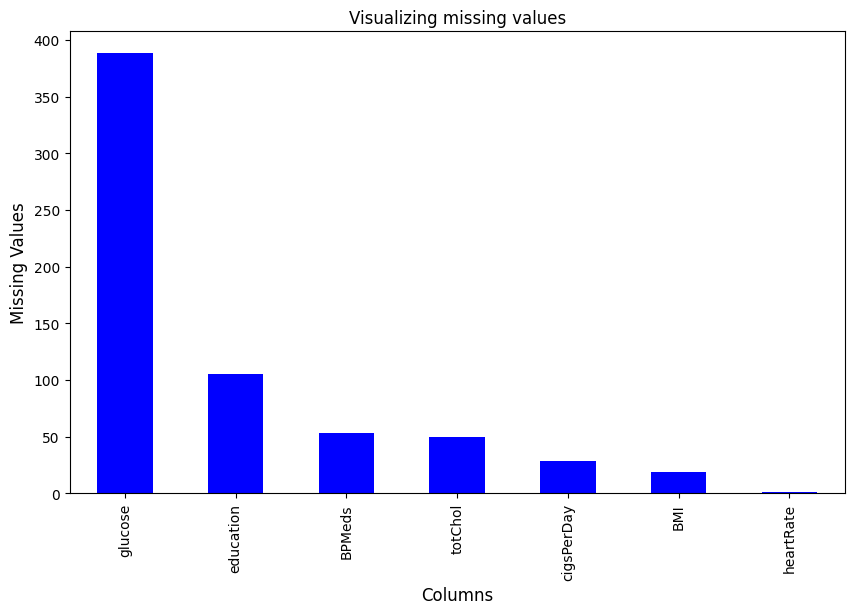

In [12]:
# Chart representation of columns with missing values

# Make a new dataframe of just the categories with a nonzero quantity of missing values
missing = df.isna().sum()
missing = missing[missing > 0]
missing = missing.sort_values(ascending=False) # Sort in descending order for ease of viewing

# Plot the bar chart
missing.plot(kind='bar', figsize=(10,6), color='blue')
plt.xlabel('Columns', fontsize=12)
plt.ylabel('Missing Values', fontsize=12)
plt.title('Visualizing missing values')
plt.show()


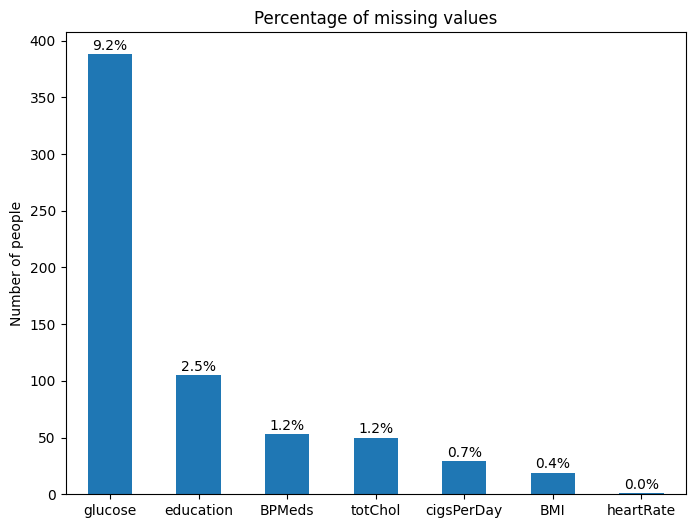

In [18]:
plt.figure(figsize=(8,6))

missing = df.isna().sum()
missing = missing[missing > 0]
missing = missing.sort_values(ascending=False) # Sort in descending order for ease of viewing

# Creating a bar plot and storing the AxesSubPlot object in 'ax'
ax = missing.plot(kind='bar')

# Rotate x-ticks for ease of reading
plt.xticks(rotation=0)

# Label the y-axis
plt.ylabel('Number of people')

plt.title("Percentage of missing values")

# Overlay the value counts above each bar
for p in ax.patches:
    percentage = (p.get_height() / df.shape[0]) * 100
    ax.annotate(f'{percentage:.1f}%',
               (p.get_x() + p.get_width() / 2., p.get_height()), # Label position
                ha='center', va='center', xytext=(0,6), textcoords='offset points')

plt.show()

We can clearly see that there is a large amount of missing values, particularly in the 'glucose' column.

In order to reliably train our classification models, it will be necessary to deal with this missing data appropriately. We will employ two imputation techniques using K-Nearest Neighbors, and simple imputation using a statistical value such as mean, median, or mode. 

We will then observe and compare the effect of these approaches via the results of the models.



In [6]:
# Investigating duplicate data
print(f'Duplicate rows: {df.duplicated().sum()}')

Duplicate rows: 0


Investigating the variables

In [7]:
df.describe()

,male,age,education,currentSmoker,cigsPerDay,BPMeds,prevalentStroke,prevalentHyp,diabetes,totChol,sysBP,diaBP,BMI,heartRate,glucose,TenYearCHD
count,4240.000000,4240.000000,4135.000000,4240.000000,4211.000000,4187.000000,4240.000000,4240.000000,4240.000000,4190.000000,4240.000000,4240.000000,4221.000000,4239.000000,3852.000000,4240.000000
mean,0.429245,49.580189,1.979444,0.494104,9.005937,0.029615,0.005896,0.310613,0.025708,236.699523,132.354599,82.897759,25.800801,75.878981,81.963655,0.151887
std,0.495027,8.572942,1.019791,0.500024,11.922462,0.169544,0.076569,0.462799,0.158280,44.591284,22.033300,11.910394,4.079840,12.025348,23.954335,0.358953
min,0.000000,32.000000,1.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,107.000000,83.500000,48.000000,15.540000,44.000000,40.000000,0.000000
25%,0.000000,42.000000,1.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,206.000000,117.000000,75.000000,23.070000,68.000000,71.000000,0.000000
50%,0.000000,49.000000,2.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,234.000000,128.000000,82.000000,25.400000,75.000000,78.000000,0.000000
75%,1.000000,56.000000,3.000000,1.000000,20.000000,0.000000,0.000000,1.000000,0.000000,263.000000,144.000000,90.000000,28.040000,83.000000,87.000000,0.000000
max,1.000000,70.000000,4.000000,1.000000,70.000000,1.000000,1.000000,1.000000,1.000000,696.000000,295.000000,142.500000,56.800000,143.000000,394.000000,1.000000


Variable summary

Target Variable (Nominal)
- 'TenYearCHD' : 10 year risk of developing CHD

Nominal Data:
- 'male' : The patient's sex
- 'currentSmoker' : Whether or not the patient smokes
- 'BPMeds' : Whether or not the patient is taking blood pressure medication
- 'prevalentStroke' : Whether or not the patient has had a stroke
- 'prevalentHyp' : Whether or not the patient has been hypertensive
- 'diabetes' : Whether or not the patient has diabetes

Ordinal Data
- 'education' : The patient's education level (no further detail provided)

Continuous Data
- 'age' : The patient's age
- 'cigsPerDay' : Average number of cigarettes smoked per day
- 'totChol' : Total cholesterol (mg/dL)
- 'sysBP' : Systolic Blood Pressure (mmHg)
- 'diaBP' : Diastolic Blood Pressure (mmHg)
- 'BMI' : Body Mass Index
- 'heartRate' : Heart rate
- 'glucose' : Glucose level (mg/dL)

Investigating the distributions of continuous data

In [32]:
# Function to plot the distributions for continuous variables

sns.set_theme(palette='deep')

def dist_plot(data, variable, median=False, mean=False, unit=None):
    sns.displot(data[variable], height = 5, aspect = 11/6, bins = 30, kde = True)
    if median == True:
        plt.axvline(data[variable].median(), color='red', linestyle='--', label=f'Median = {data[variable].median():.2f} {unit}')
    if mean == True:
        plt.axvline(data[variable].mean(), color='green', linestyle='--', label=f'Mean = {data[variable].mean():.2f} {unit}')
    plt.ylabel('Number of people')
    plt.xlabel(f'{variable} {unit}')
    plt.title(f'{variable}')
    plt.legend()
    plt.show()

# Units for the continuous variables
units = ['years', 'num/day', 'mg/dL', 'mmHg', 'mmHg', 'kg/m^2', 'bpm','mg/dL']
cont_variables = ['age', 'cigsPerDay', 'totChol', 'sysBP', 'diaBP', 'BMI', 'heartRate', 'glucose']

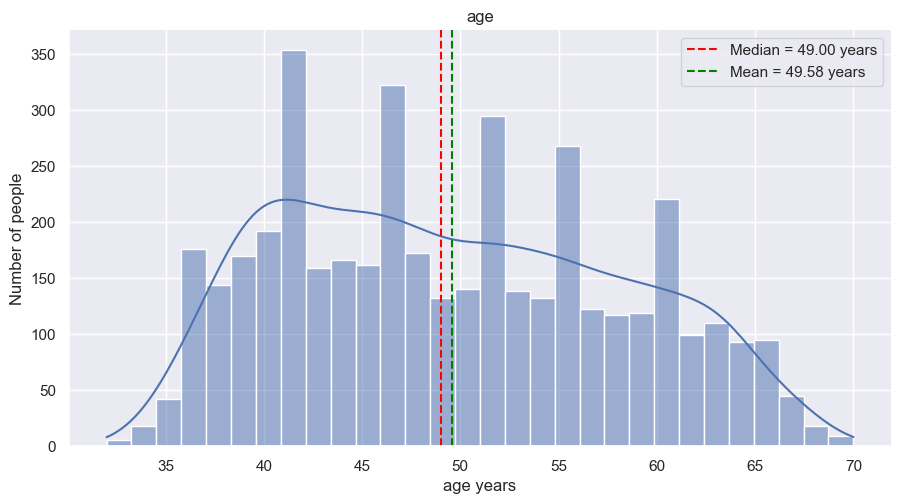

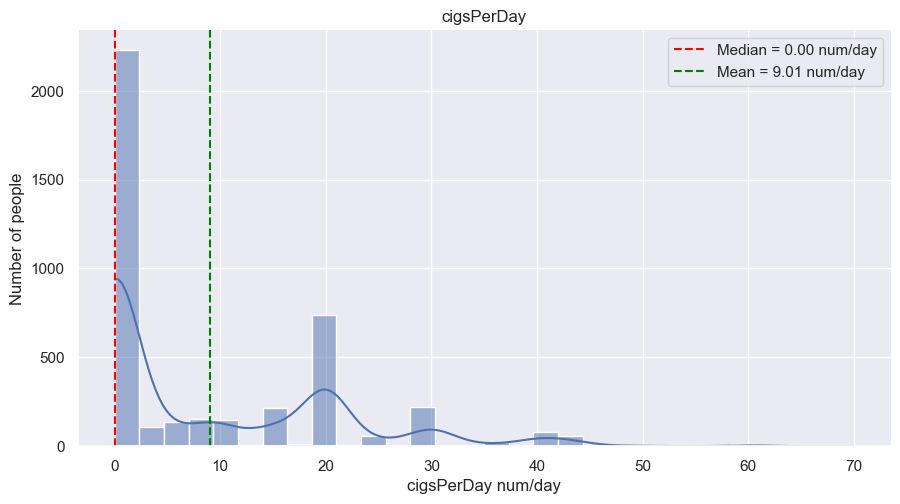

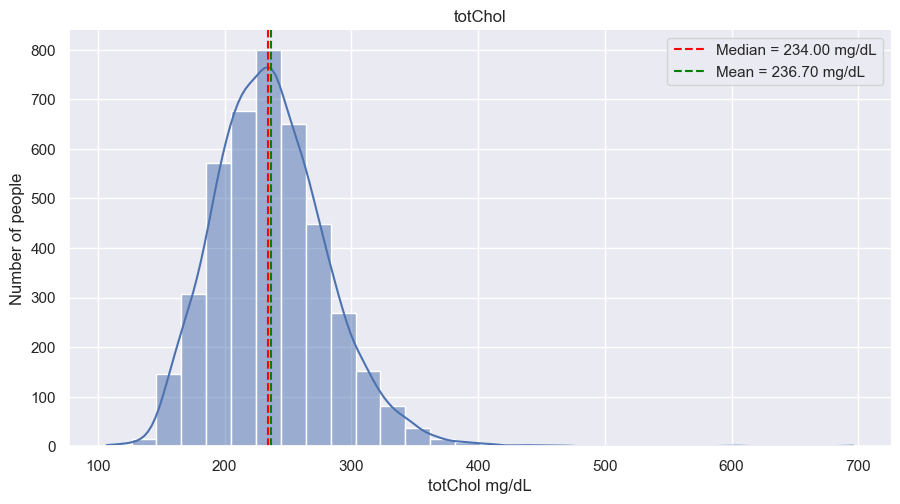

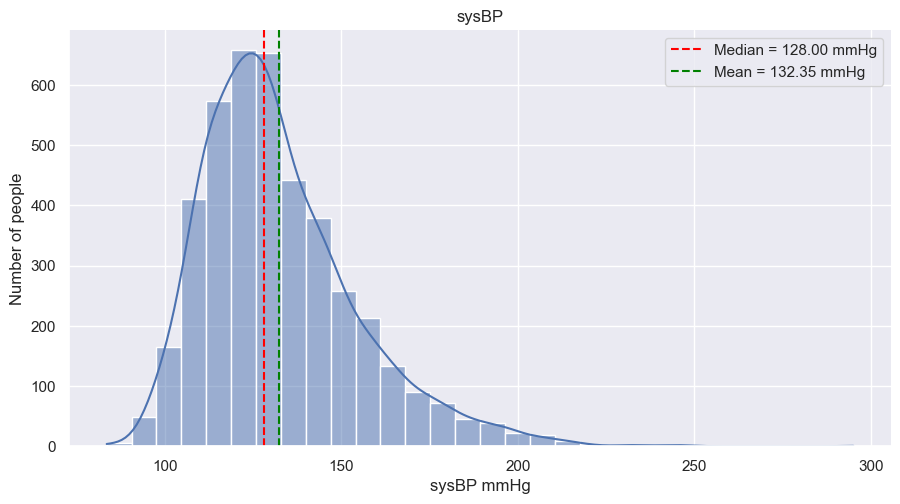

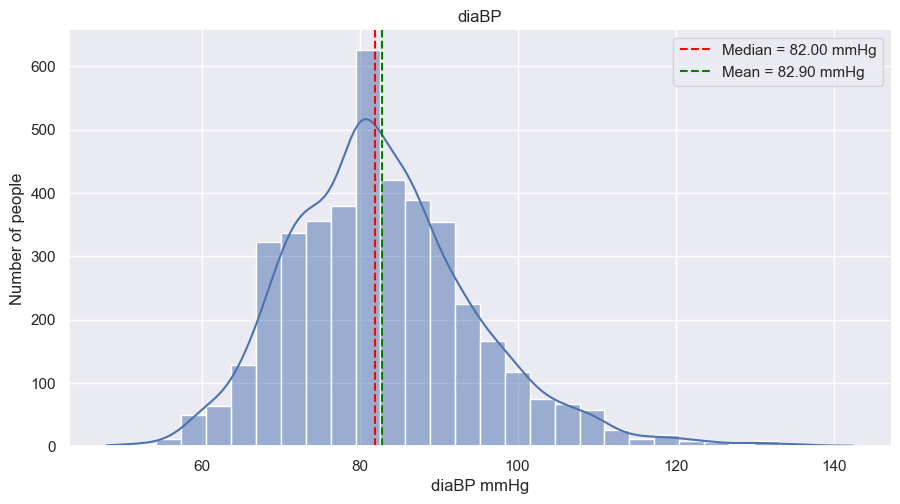

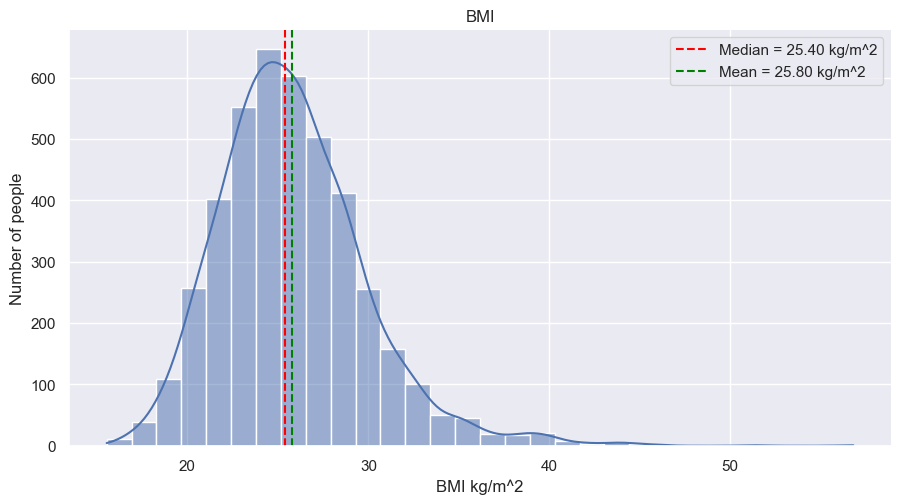

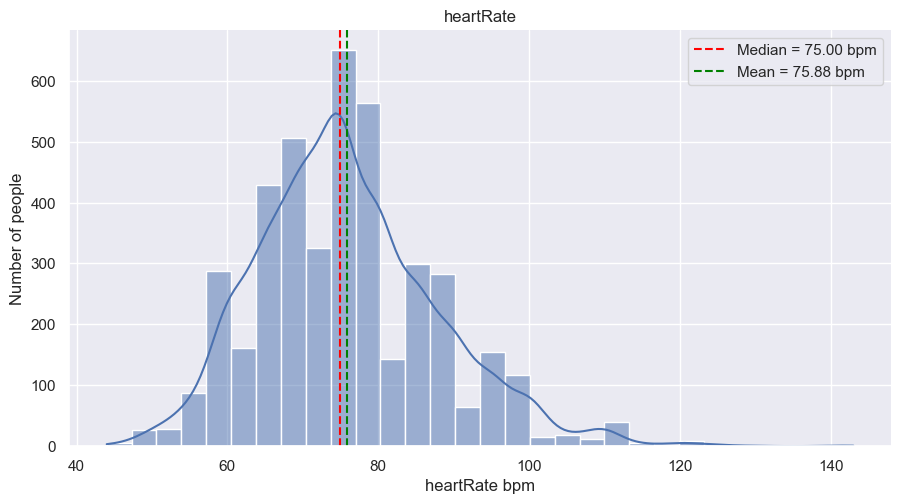

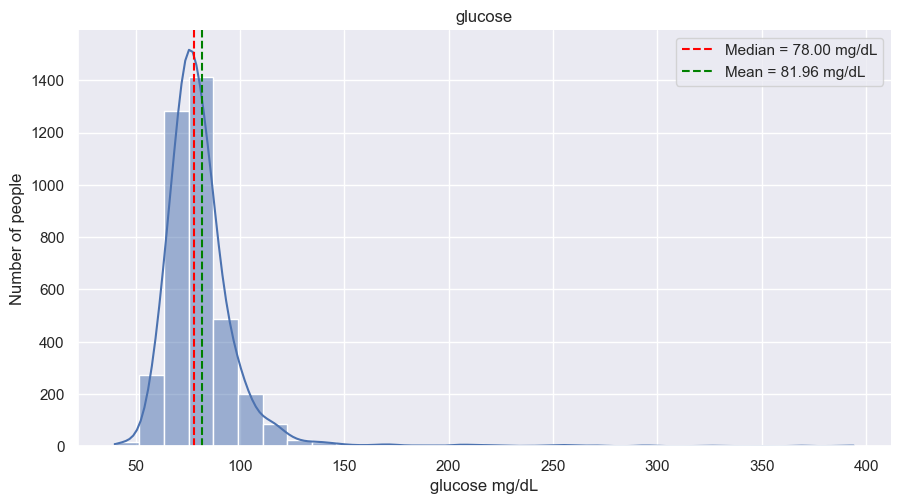

In [32]:
# Plotting the graphs for continuous data

for variable, unit in zip(cont_variables, units):
    dist_plot(df, variable, median=True, mean=True, unit=unit)

Do note the right skew of essentially all of these plots, evidenced by the mean being greater than the median for all continuous variables. 

One notable skew is found in sysBP, where the spread between the median and mean is greatest (with the exception of cigarettes per day). This will require further investigation when it comes time to process the data for model training.

Text(0.5, 1.0, 'Systolic Blood Pressure (mmHg)')

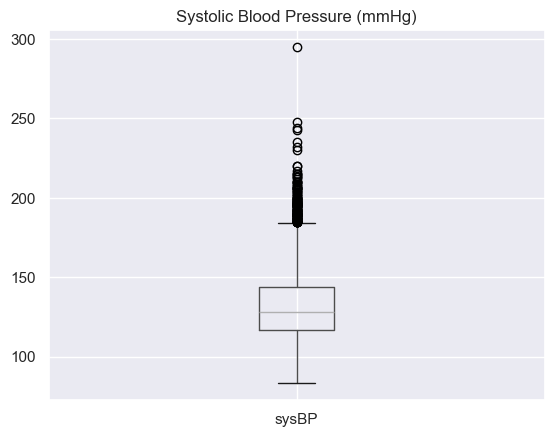

In [33]:
# Creating a boxplot to better visualize outliers in sysBP

df.boxplot(column='sysBP')
plt.title('Systolic Blood Pressure (mmHg)')

Text(0.5, 1.0, 'Diastolic Blood Pressure (mmHg)')

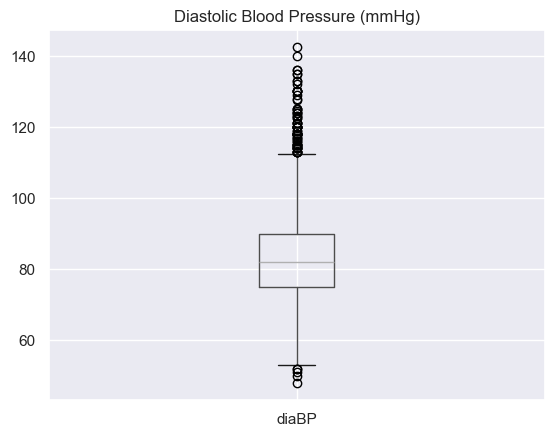

In [35]:
# Investigating outliers in diaBP

df.boxplot(column='diaBP')
plt.title('Diastolic Blood Pressure (mmHg)')

Text(0.5, 1.0, 'BMI (kg/m^2)')

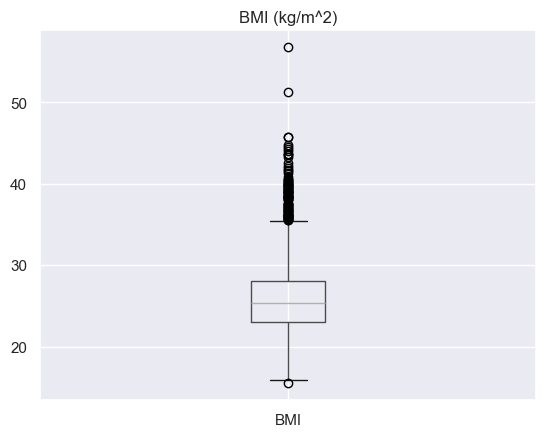

In [34]:
# Create a boxplot to view BMI data outliers

df.boxplot(column='BMI')
plt.title('BMI (kg/m^2)')

Investigating Discrete Features

In [45]:
# Create a list of the categorical variables to be visualized

cat_data = ['male','currentSmoker','BPMeds','prevalentStroke','prevalentHyp','diabetes','education']

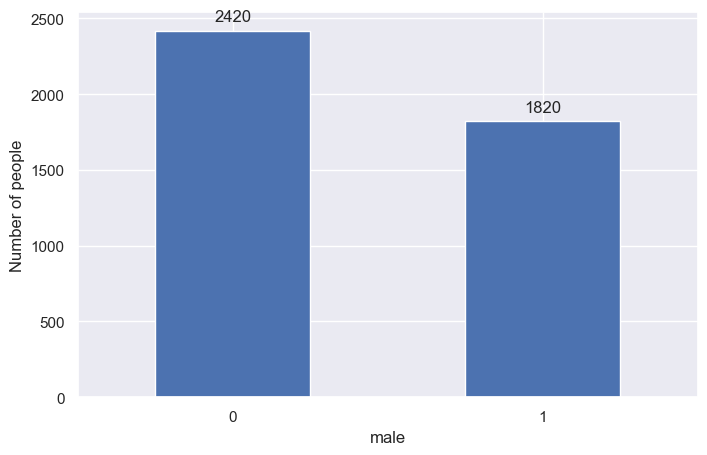

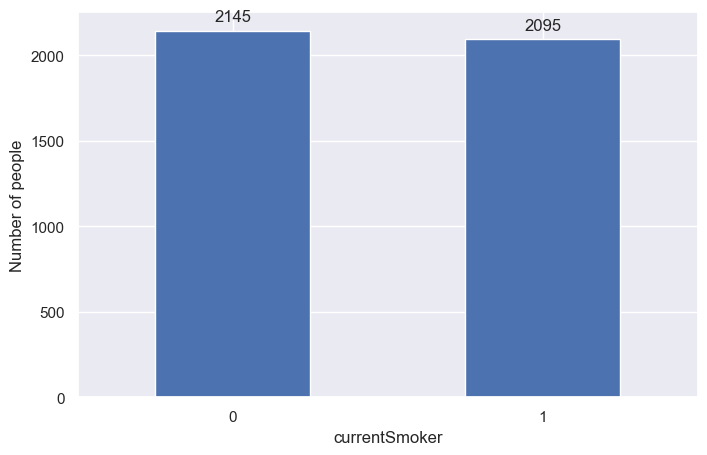

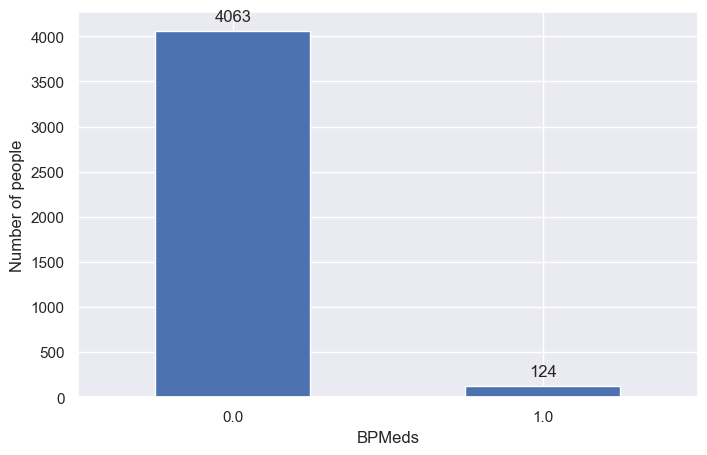

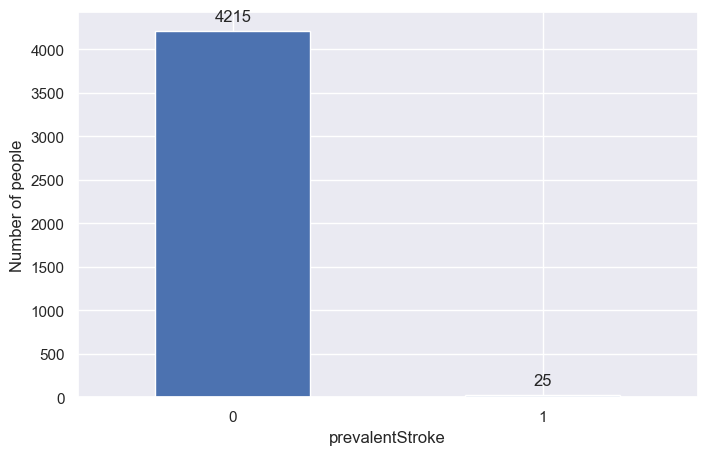

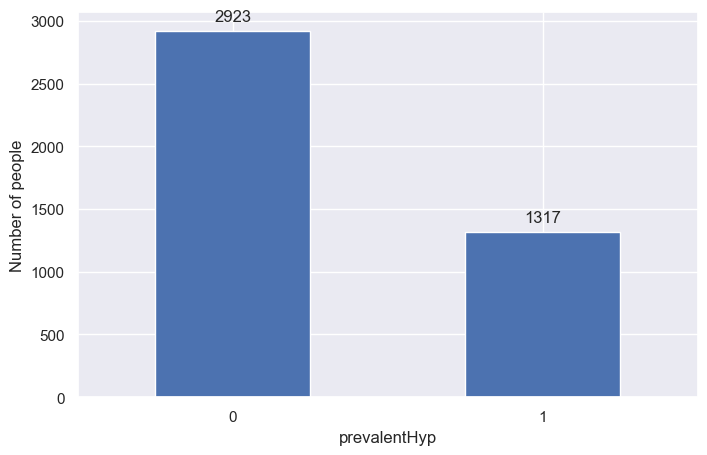

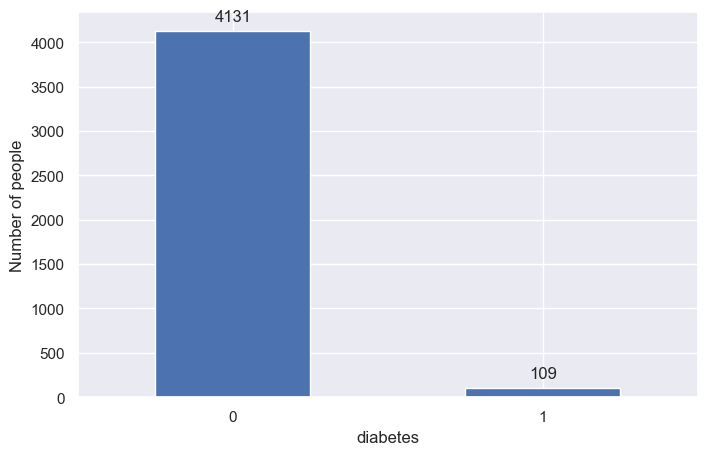

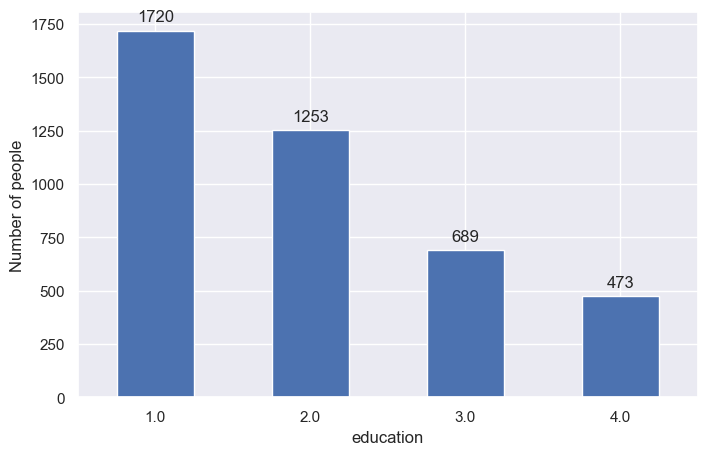

In [46]:
# Loop through the list of categorical data
for data in cat_data:
    plt.figure(figsize=(8,5))

    # Creating a bar plot and storing the AxesSubPlot object in 'ax'
    ax = df[data].value_counts().plot(kind='bar')

    # Rotate x-ticks for ease of reading
    plt.xticks(rotation=0)

    # Label the y-axis
    plt.ylabel('Number of people')

    # Overlay the value counts above each bar
    for p in ax.patches:
        ax.annotate(f'{p.get_height():.0f}',
                   (p.get_x() + p.get_width() / 2., p.get_height()), # Label position
                    ha='center', va='center', xytext=(0,10), textcoords='offset points')

    plt.show()

Within the discrete variables, we view some notable imbalances between the number of males to females, those who are on blood pressure medication and those who are not, those with prevalent strokes, hypertension, and diabetes.

Additionally, we note the following:
- A greater number of people are less educated in this dataset (Assuming 4 is the greatest level of education)
- While 1,317 people were noted to have prevalent hypertension, only 124 are actually on blood pressure medication
- Only 25 out of the over 4,000 patients are reported to have suffered a stroke
- Only 109 patients have diabetes

Let us now turn our attention to analyzing the target variable of TenYearCHD

We will begin by viewing the relationship between ten year CHD risk, and our continuous variables

In [42]:
# Function to overlay distribution of positive CHD onto continuous variables
sns.set_theme(palette='deep')

def comp_histplot(cont_var, unit):
    bin_edges = plt.hist(df[cont_var], bins=30)[1]

    # Plotting the histogram for the independent variable
    sns.histplot(df[cont_var], bins=bin_edges, kde=True, color='lightblue',label='All',alpha=0.7)

    # Overlaying the histogram for the TenYearCHD
    sns.histplot(df[df['TenYearCHD']==1][cont_var], bins=bin_edges, kde=True, color='red', label='10 year CHD', alpha=0.5)

    # Setting the labels and title
    plt.ylabel('Number of people')
    plt.xlabel(f'{cont_var} {unit}')
    plt.title(f'Comparing {cont_var} with 10 Year CHD Risk')
    plt.legend()
    plt.show()

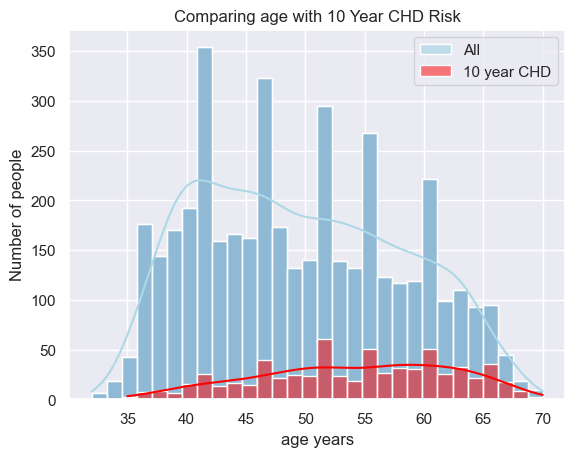

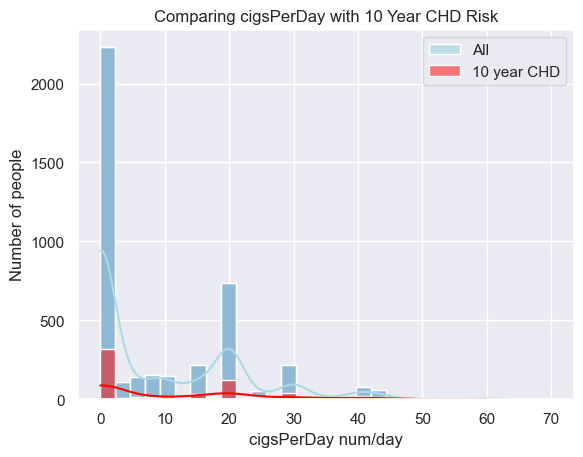

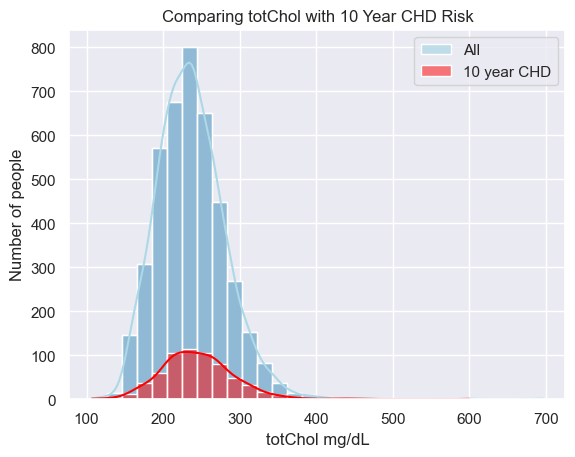

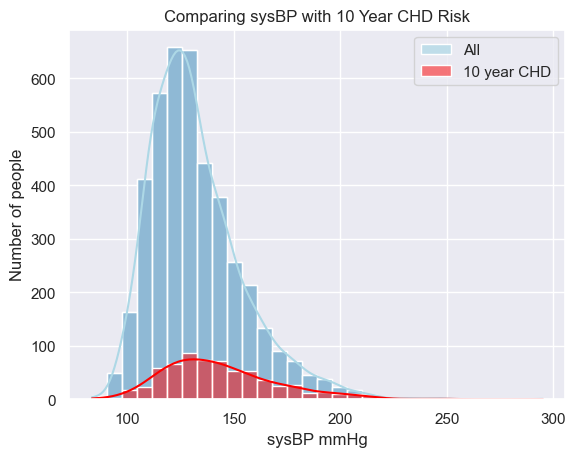

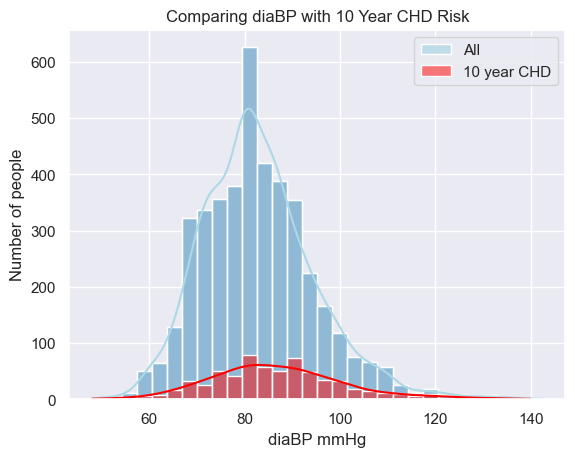

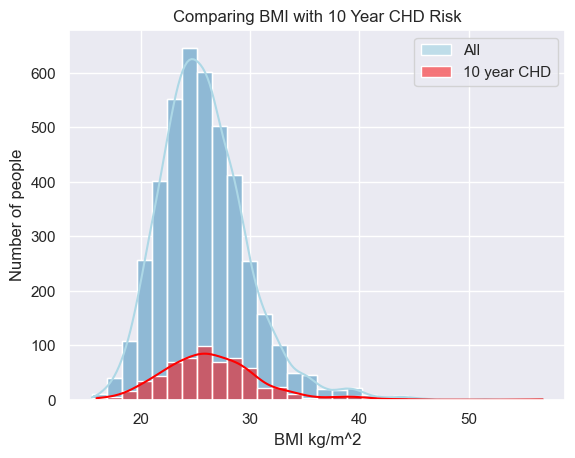

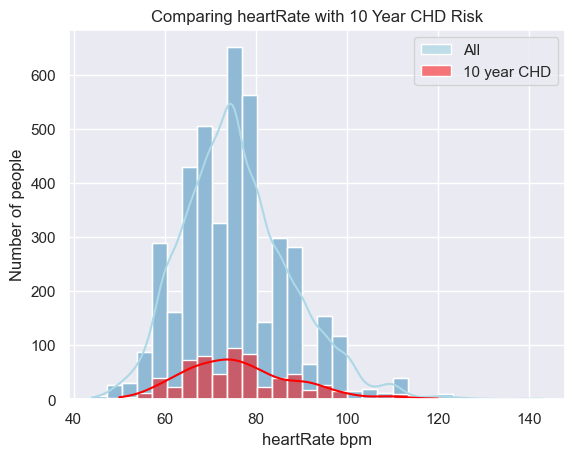

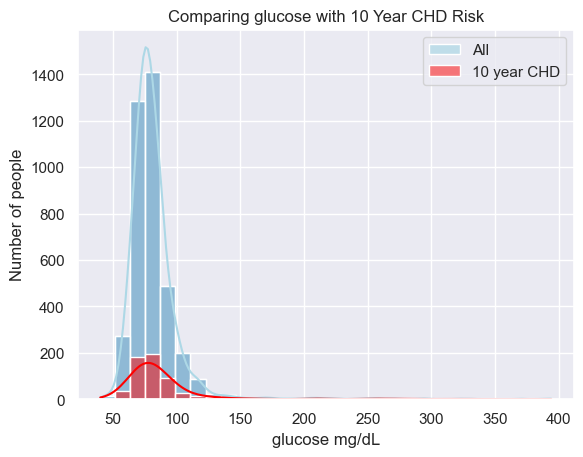

In [43]:
for variable, unit in zip(cont_variables, units):
    comp_histplot(variable, unit)

Overlaying the histograms of our continuous independent variables with the target, it is difficult to glean any notable association.

The most stark of which appears to be age, where the number of people with a 10 year CHD risk appear to be more concentrated in the higher ages.

Let us now view the relationship between ten year CHD risk and our discrete independent variables in terms of proportion.

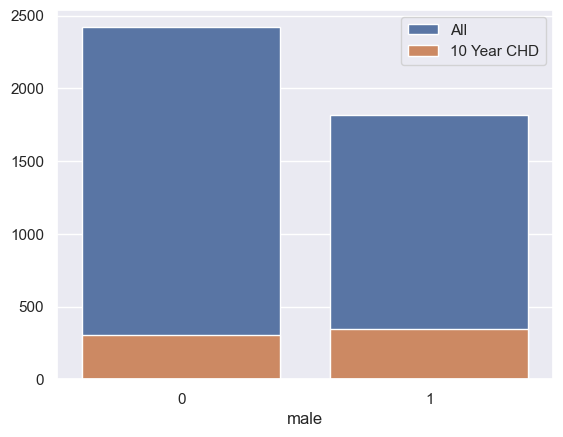

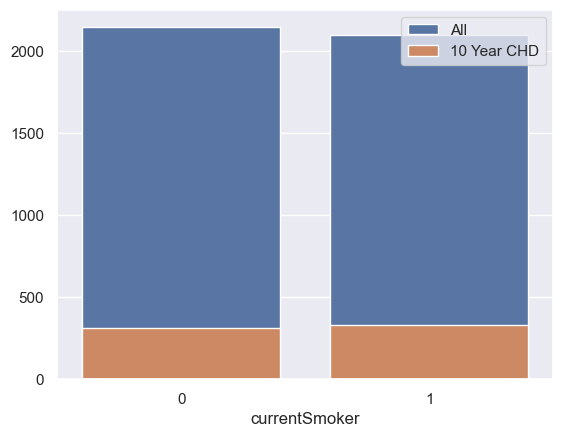

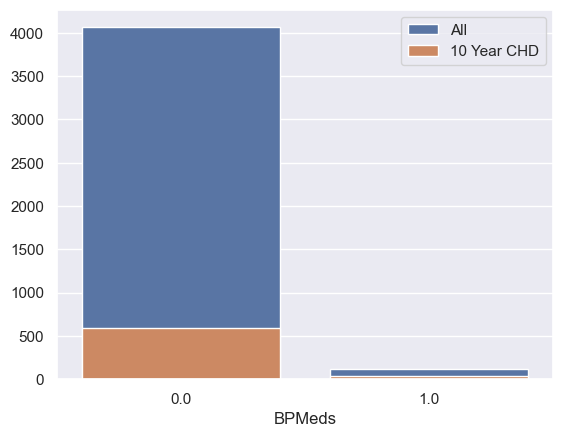

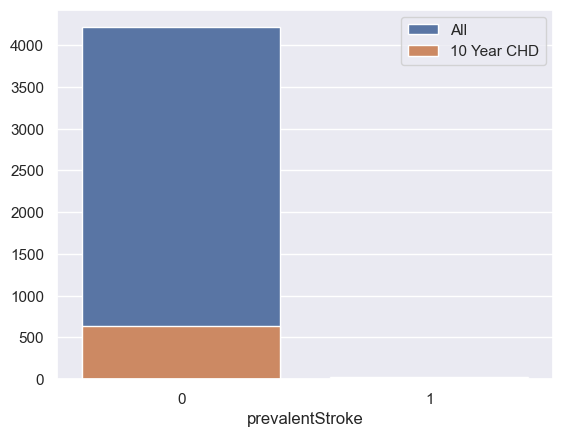

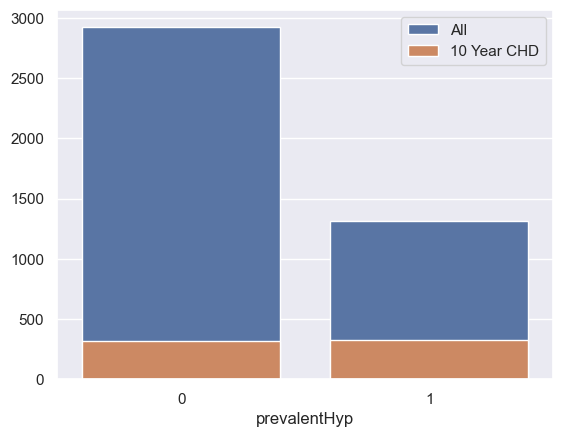

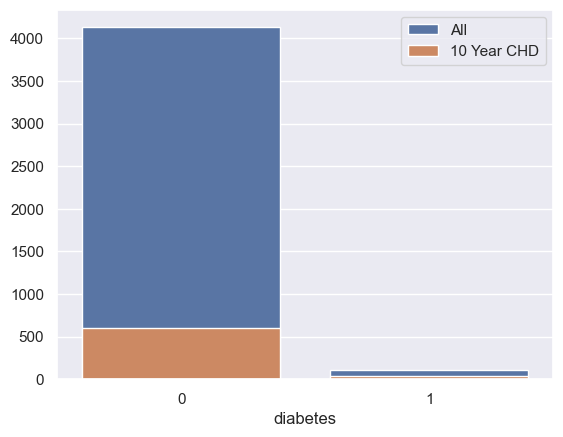

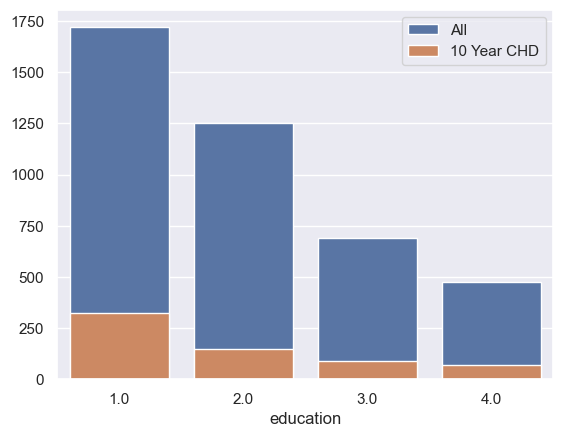

In [58]:
# Create a list of the categorical variables to be visualized
cat_data = ['male','currentSmoker','BPMeds','prevalentStroke','prevalentHyp','diabetes','education']

# Loop through the list of categorical data
for data in cat_data:
    totals = df[data].value_counts()
    chd_counts = df[df['TenYearCHD']==1][data].value_counts()
    ax = sns.barplot(x=totals.index, y=totals.values, label='All')
    sns.barplot(x=chd_counts.index, y=chd_counts.values, label='10 Year CHD')

    plt.show()

# FIGURE OUT HOW TO OVERLAY PERCENTAGES

When viewing this proportional data, we note the following:
- A higher proportion of males are at risk of heart disease than females
- The fact that someone is a smoker only raises their risk of developing CHD by a small amount
- A larger portion of people with prevalent hypertension are at risk

With regard to our dependent variable, we should consider the possibility of class imbalance in order to mitigate biased results from the classification model

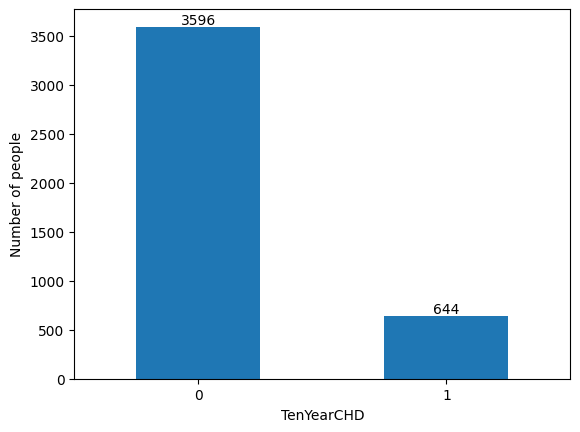

In [4]:
# Creating a bar plot and storing the AxesSubPlot object in 'ax'
ax = df['TenYearCHD'].value_counts().plot(kind='bar')

# Rotate x-ticks for ease of reading
plt.xticks(rotation=0)

# Label the y-axis
plt.ylabel('Number of people')

# Overlay the value counts above each bar
for p in ax.patches:
    ax.annotate(f'{p.get_height():.0f}',
               (p.get_x() + p.get_width() / 2., p.get_height()), # Label position
                ha='center', va='center', xytext=(0,5), textcoords='offset points')

plt.show()

Clearly, there are significantly more people without a 10 year risk of developing heart disease than those with a risk. The target variable has an imbalance ratio of ~5:1 which means that it is moderately imbalanced.

This imbalance must be addressed before model training. For the purposes of this analysis, we will use SMOTENC. This method will generate synthetic data to oversample the minority (positive risk for CHD). This method is chosen over SMOTE because our dataset contains both numerical and categorical features.

# Correlation
We now take a holistic view at the linear relationships between all of the variables by viewing the correlation matrix

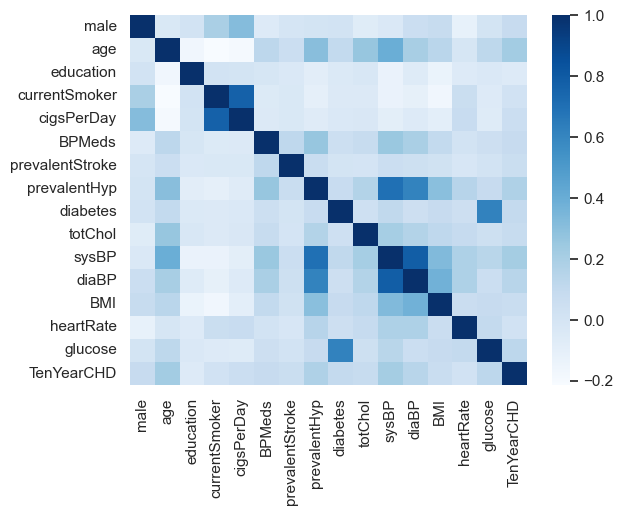

In [56]:
# Correlation heatmap
plot = sns.heatmap(df.corr(), cmap='Blues', annot=False)

In [7]:
df.corr()

,male,age,education,currentSmoker,cigsPerDay,BPMeds,prevalentStroke,prevalentHyp,diabetes,totChol,sysBP,diaBP,BMI,heartRate,glucose,TenYearCHD
male,1.000000,-0.029014,0.017415,0.197026,0.317143,-0.052504,-0.004550,0.005853,0.015693,-0.070413,-0.035879,0.058199,0.081871,-0.116932,0.005979,0.088374
age,-0.029014,1.000000,-0.166356,-0.213662,-0.192959,0.123052,0.057679,0.306799,0.101314,0.262554,0.394053,0.205586,0.136096,-0.012843,0.122356,0.225408
education,0.017415,-0.166356,1.000000,0.018528,0.008323,-0.010898,-0.035142,-0.081726,-0.038749,-0.023613,-0.129496,-0.061919,-0.137747,-0.054182,-0.035843,-0.054248
currentSmoker,0.197026,-0.213662,0.018528,1.000000,0.769774,-0.048927,-0.032980,-0.103710,-0.044285,-0.046488,-0.130281,-0.107933,-0.167857,0.062686,-0.056726,0.019448
cigsPerDay,0.317143,-0.192959,0.008323,0.769774,1.000000,-0.046155,-0.032711,-0.066645,-0.037089,-0.026479,-0.088797,-0.056715,-0.093293,0.075564,-0.058886,0.057755
BPMeds,-0.052504,0.123052,-0.010898,-0.048927,-0.046155,1.000000,0.117370,0.261067,0.052060,0.080623,0.254194,0.194122,0.100702,0.015230,0.051197,0.087519
prevalentStroke,-0.004550,0.057679,-0.035142,-0.032980,-0.032711,0.117370,1.000000,0.074791,0.006955,0.000105,0.057000,0.045153,0.025909,-0.017674,0.018440,0.061823
prevalentHyp,0.005853,0.306799,-0.081726,-0.103710,-0.066645,0.261067,0.074791,1.000000,0.077752,0.163632,0.696656,0.615840,0.301344,0.146815,0.086656,0.177458
diabetes,0.015693,0.101314,-0.038749,-0.044285,-0.037089,0.052060,0.006955,0.077752,1.000000,0.040348,0.111265,0.050260,0.087068,0.048986,0.617630,0.097344
totChol,-0.070413,0.262554,-0.023613,-0.046488,-0.026479,0.080623,0.000105,0.163632,0.040348,1.000000,0.208734,0.164698,0.115992,0.091127,0.046538,0.082369


In this correlation matrix, we can take note of some relationships that we can take a closer look at in the preprocessing stage.

Note the following:
- Relationship between glucose level and diabetes: One's diabetes grade is defined as the range in which their glucose level falls. Since glucose level is used to determine a diabetes diagnosis, it is rather redundant to keep the diabetes column in this case.
- Relationship between sysBP and diaBP: systolic and diastolic blood pressure are always taken together. Again, a new feature must be engineered that is reresentative of the data they provide, without overcomplicating our dataset. The solution is to create a 'Mean Arterial Pressure' column.
- Relationship between 'currentSmoker' and 'cigsPerDay': The 'currentSmoker' column can be dropped because everyone who has a nonzero value for 'cigsPerDay' must be a current smoker themselves.

# Feature Importance Testing
We notice a few independent features with very weak linear relationships to CHD risk, those being 'education', 'cigsPerDay', and 'heartRate.' 

The correlation matrix displays only the linear correlation between variables, so we cannot eliminate features simply based on a low correlation value, as there could exist a nonlinear relationship.

In the following cell, the random forest classifier is employed to help us determine what features are most influential

In [22]:
from sklearn.ensemble import RandomForestClassifier
from sklearn.model_selection import train_test_split
import pandas as pd

# Assuming your dataframe is 'df' and 'heart_disease' is the target
X = df.drop(columns='TenYearCHD')
y = df['TenYearCHD']

# Split into training and testing sets
X_train, X_test, y_train, y_test = train_test_split(X, y, random_state=42)

# Fit Random Forest model
rf = RandomForestClassifier(random_state=42)
rf.fit(X_train, y_train)

# Get feature importances
importances = rf.feature_importances_

# Create a DataFrame for visualization
importance_df = pd.DataFrame({'Feature': X.columns, 'Importance': importances})
importance_df = importance_df.sort_values(by='Importance', ascending=False)
print(importance_df)


            Feature  Importance
10            sysBP    0.130849
12              BMI    0.129901
11            diaBP    0.120071
9           totChol    0.119791
14          glucose    0.118247
1               age    0.118215
13        heartRate    0.099348
4        cigsPerDay    0.053758
2         education    0.041375
0              male    0.019219
7      prevalentHyp    0.018675
3     currentSmoker    0.011643
5            BPMeds    0.008481
8          diabetes    0.006412
6   prevalentStroke    0.004014


In [23]:
# Assess the predictive acurracy of the random-forest model
print(f'RD train accuracy: {rf.score(X_train, y_train):.2f}')
print(f'RD test accuracy: {rf.score(X_test, y_test):.2f}')

RD train accuracy: 1.00
RD test accuracy: 0.86


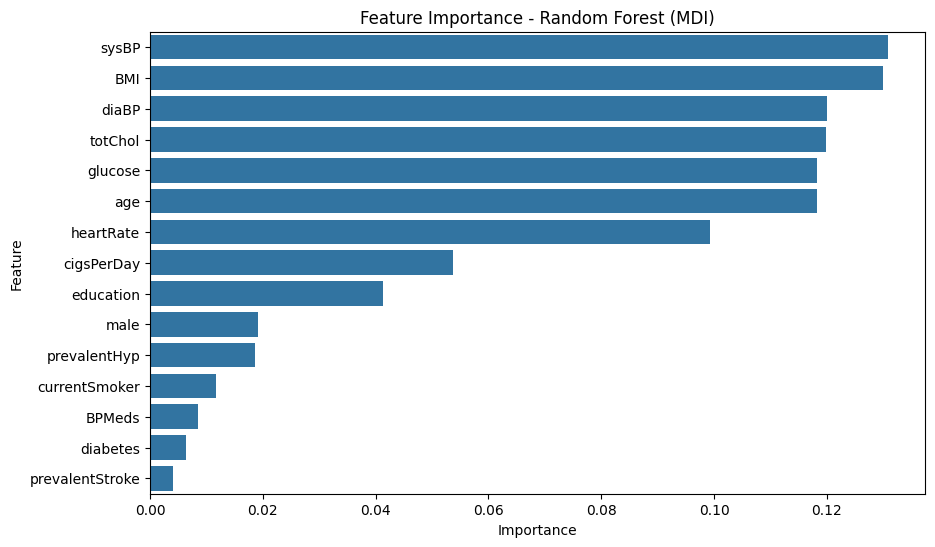

In [25]:
# Plot a chart of our random-forest feature importances
plt.figure(figsize=(10, 6))
sns.barplot(x='Importance', y='Feature', data=importance_df)
plt.title('Feature Importance - Random Forest (MDI)')
plt.show()

The results of our test of feature importance using a random forest model has shown us the following:
The most influential independent features for predicting heart disease risk are:
- Systolic Blood Pressure
- BMI
- Diastolic Blood Pressure (We will combine 'sysBP' and 'diaBP' into one feature)
- Total Cholesterol
- Glucose
- Age

The least influential are
- Stroke Prevalence
- Diabetes
- Blood Pressure Medication
- Hypertension Prevalence

The result for hypertension prevalence being so low in terms of importance seems counterintuitive given what is widely known about high blood pressure and heart disease, and thus prompts further investigation. 

Let us now use a chi-square test to better understand the association of hypertension prevalence to the 10 year risk of heart disease

In [9]:
import pandas as pd
from scipy.stats import chi2_contingency

# Create a contingency table
contingency_table = pd.crosstab(df['prevalentHyp'], df['TenYearCHD'])

# Perform Chi-Square test
chi2, p, dof, expected = chi2_contingency(contingency_table)

# Output results
print("Chi-Square Statistic:", chi2)
print("P-Value: ", p)

# Check significance
alpha = 0.05  # 5% significance level
if p < alpha:
    print("Reject Null Hypothesis - Significant association.")
else:
    print("Fail to Reject Null - No significant association.")

Chi-Square Statistic: 132.45628623925992
P-Value:  1.1889609489706164e-30
Reject Null Hypothesis - Significant association.


As we can see, prevalent hypertension's importance may be ranked low by the random forest feature importances, but this unintuitive result was investigated further and shown to be statistically relevant by way of the chi-square test.

An explanation for this discrepancy could be due to the random forest recognizing other features as more important than hypertension, and pushing it lower in the ranks, but not disregarding its predictive power. Additionally, it may not have recognized a direct, strong relationship between hypertension and heart disease, which may have a more subtle effect via or in concert with other features.